In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('dataset/AFD_Dataset.csv')

In [4]:
null_counts = data.isnull().sum()
# Print the number of null values
print(f"{null_counts.sum()} null entries have been found in the dataset\n")
# Drop null values
data.dropna(inplace=True)          # or df_data = df_data.dropna()

# Find and handle duplicates
duplicate_count = data.duplicated().sum()
# Print the number of duplicate entries
print(f"{duplicate_count} duplicate entries have been found in the dataset\n")
# Remove duplicates
data.drop_duplicates(inplace=True)  # or df_data = df_data.drop_duplicates()
# Display relative message
print(f"All duplicates have been removed\n")

# Reset the indexes
data.reset_index(drop=True, inplace=True)

# Inspect the dataset for categorical columns
print("Categorical columns:",data.select_dtypes(include=['object']).columns.tolist(),'\n')

# Print the first 5 lines
data.head()

0 null entries have been found in the dataset

0 duplicate entries have been found in the dataset

All duplicates have been removed

Categorical columns: [] 



,HR_mean,HR_std,RR_mean,RR_rmssd,GSR_mean,GSR_std,TEMP_mean,ACC_mean,ACC_std,Tap_speed,HR_GSR,RR_HR_ratio,ACC_TEMP,HR_sq,GSR_sq,PCA_1,PCA_2
0,79.967142,6.556722,0.609219,22.329772,0.277184,0.067257,36.729621,1.308264,0.417481,3.430846,22.165590,0.007618,48.052049,6394.743724,0.076831,4.000872,7.678727
1,73.617357,3.897629,0.713961,19.179930,0.373814,0.051218,36.822024,1.266800,0.112102,3.236542,27.519186,0.009698,46.646126,5419.515250,0.139737,-2.556327,10.419651
2,81.476885,3.363602,0.758639,17.331293,0.311588,0.057534,36.649607,1.155547,0.267220,3.767063,25.387217,0.009311,42.350344,6638.482851,0.097087,5.163345,12.772802
3,90.230299,4.993251,0.988769,33.303991,0.390401,0.050998,35.917251,1.014937,0.295834,3.537984,35.225984,0.010958,36.453753,8141.506779,0.152413,14.936810,-2.608467
4,72.658466,4.659631,0.855655,28.287458,0.457170,0.043327,36.453373,1.004500,0.301591,3.717846,33.217267,0.011776,36.617416,5279.252718,0.209004,-2.923167,1.269325


# K-Means Cluster

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [6]:
scaler_afd = StandardScaler()
afd_scaled = scaler_afd.fit_transform(data)

# Binary Clustering

In [7]:
kmeans_binary_afd = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init=20,
    random_state=42
)

binary_labels_afd = kmeans_binary_afd.fit_predict(afd_scaled)
data["Binary_Label"] = binary_labels_afd

In [8]:
kmeans_multi_afd = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=20,
    random_state=42
)

multi_labels_afd = kmeans_multi_afd.fit_predict(afd_scaled)
data["Multi_Label"] = multi_labels_afd

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HR_mean       12000 non-null  float64
 1   HR_std        12000 non-null  float64
 2   RR_mean       12000 non-null  float64
 3   RR_rmssd      12000 non-null  float64
 4   GSR_mean      12000 non-null  float64
 5   GSR_std       12000 non-null  float64
 6   TEMP_mean     12000 non-null  float64
 7   ACC_mean      12000 non-null  float64
 8   ACC_std       12000 non-null  float64
 9   Tap_speed     12000 non-null  float64
 10  HR_GSR        12000 non-null  float64
 11  RR_HR_ratio   12000 non-null  float64
 12  ACC_TEMP      12000 non-null  float64
 13  HR_sq         12000 non-null  float64
 14  GSR_sq        12000 non-null  float64
 15  PCA_1         12000 non-null  float64
 16  PCA_2         12000 non-null  float64
 17  Binary_Label  12000 non-null  int32  
 18  Multi_Label   12000 non-nu

In [10]:
data['Binary_Label'].value_counts()

0    6659
1    5341
Name: Binary_Label, dtype: int64

In [11]:
data['Multi_Label'].value_counts()

2    4324
0    4110
1    3566
Name: Multi_Label, dtype: int64

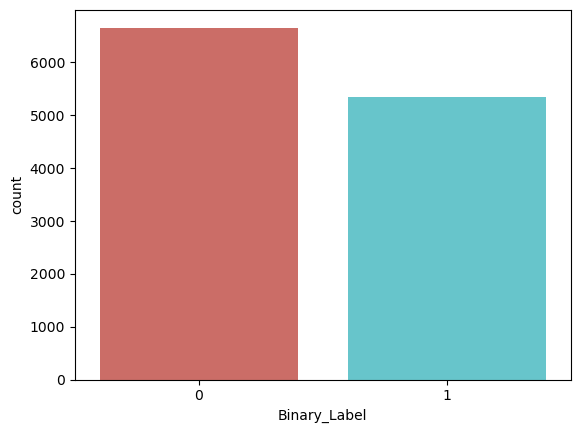

In [12]:
sns.countplot(x='Binary_Label',data=data, palette='hls')
plt.show()

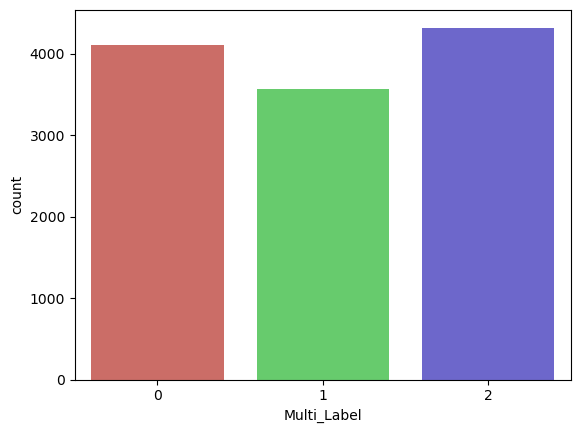

In [13]:
sns.countplot(x='Multi_Label',data=data, palette='hls')
plt.show()

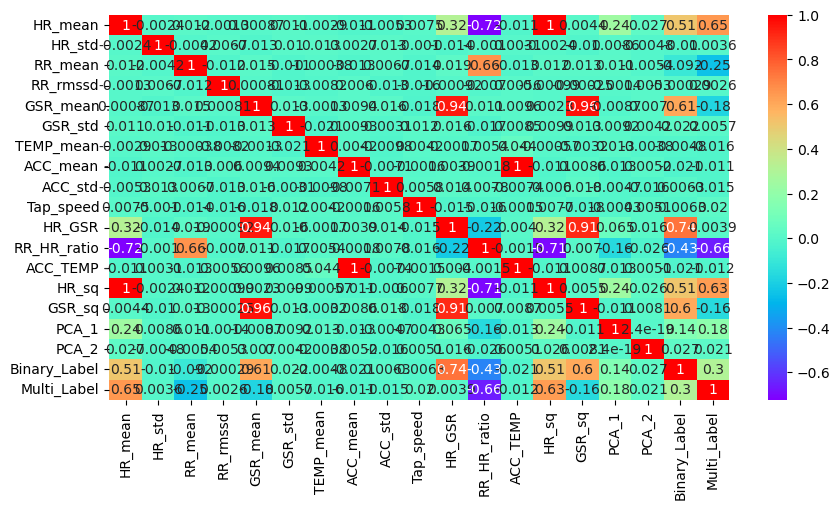

In [14]:
plt.figure(figsize = (10,5))
sns.heatmap(data.corr(), annot = True, cmap="rainbow")
plt.show()

In [15]:
data.columns

Index(['HR_mean', 'HR_std', 'RR_mean', 'RR_rmssd', 'GSR_mean', 'GSR_std',
       'TEMP_mean', 'ACC_mean', 'ACC_std', 'Tap_speed', 'HR_GSR',
       'RR_HR_ratio', 'ACC_TEMP', 'HR_sq', 'GSR_sq', 'PCA_1', 'PCA_2',
       'Binary_Label', 'Multi_Label'],
      dtype='object')

# BINARY

In [16]:
X = data[['HR_mean', 'HR_std', 'RR_mean', 'RR_rmssd', 'GSR_mean', 'GSR_std',
       'TEMP_mean', 'ACC_mean', 'ACC_std', 'Tap_speed', 'HR_GSR',
       'RR_HR_ratio', 'ACC_TEMP', 'HR_sq', 'GSR_sq', 'PCA_1', 'PCA_2']]
y = data["Binary_Label"]

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

In [18]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import joblib

# Save to a file
joblib.dump(scaler, 'models/scaler_afd.pkl')

['models/scaler_afd.pkl']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.30, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8400, 17), (8400,), (3600, 17), (3600,))

# LDA

In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(
    solver='lsqr',
    shrinkage=1   # equivalent to gamma regularization
)

lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

lda_acc = accuracy_score(y_pred, y_test)
lda_prec = precision_score(y_pred, y_test,average='weighted')
lda_rec = recall_score(y_pred, y_test,average='weighted')
lda_f1 = f1_score(y_pred, y_test,average='macro')

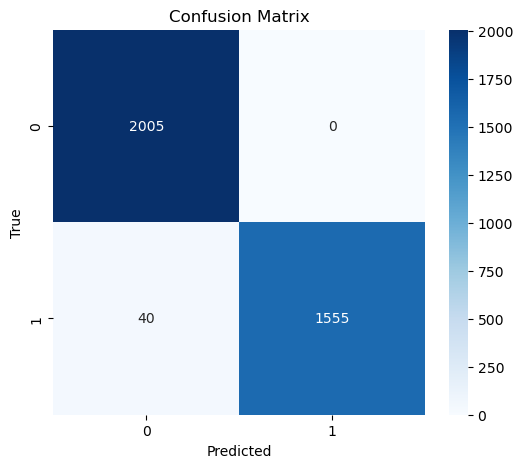

In [22]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [23]:
storeResults('LDA',lda_acc,lda_prec,lda_rec,lda_f1)

# KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=20,
    metric='jaccard'
)

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='jaccard', n_neighbors=20)

In [25]:
y_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_pred, y_test)
knn_prec = precision_score(y_pred, y_test,average='weighted')
knn_rec = recall_score(y_pred, y_test,average='weighted')
knn_f1 = f1_score(y_pred, y_test,average='macro')

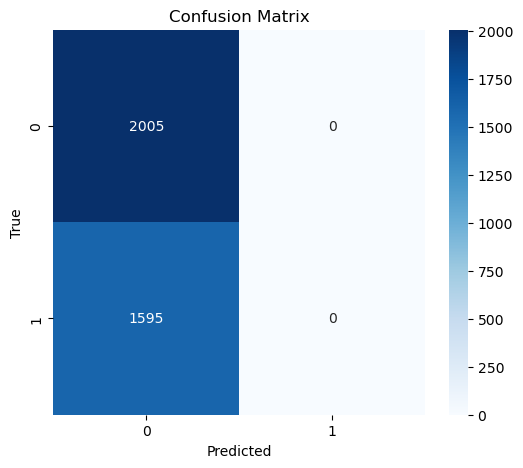

In [26]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [27]:
storeResults('KNN',knn_acc,knn_prec,knn_rec,knn_f1)

# Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='macro')

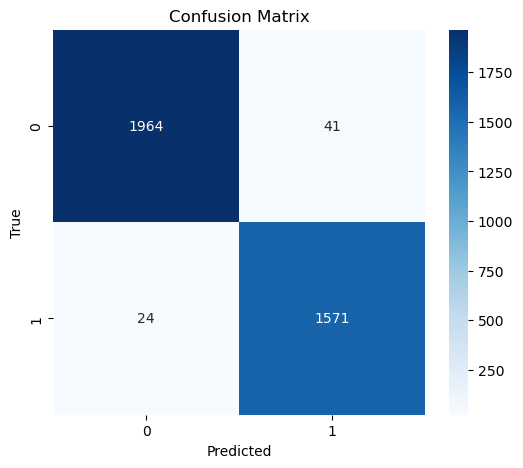

In [29]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [30]:
storeResults('Random Forest',rf_acc,rf_prec,rf_rec,rf_f1)

# Stacking Classifier

In [31]:
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier

base_learners = [
    ('lda', lda),
    ('rf', rf),
    ('knn', knn)
]

meta_learner = GradientBoostingClassifier(
    n_estimators=100,     # learning_cycles
    learning_rate=1,      # learning_rate
    min_samples_leaf=7,
    random_state=42
)

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner
)

stack.fit(X_train, y_train)

StackingClassifier(estimators=[('lda',
                                LinearDiscriminantAnalysis(shrinkage=1,
                                                           solver='lsqr')),
                               ('rf',
                                RandomForestClassifier(min_samples_leaf=10,
                                                       n_estimators=250,
                                                       random_state=42)),
                               ('knn',
                                KNeighborsClassifier(metric='jaccard',
                                                     n_neighbors=20))],
                   final_estimator=GradientBoostingClassifier(learning_rate=1,
                                                              min_samples_leaf=7,
                                                              random_state=42))

In [32]:
y_pred = stack.predict(X_test)

prop_acc = accuracy_score(y_pred, y_test)
prop_prec = precision_score(y_pred, y_test,average='weighted')
prop_rec = recall_score(y_pred, y_test,average='weighted')
prop_f1 = f1_score(y_pred, y_test,average='weighted')

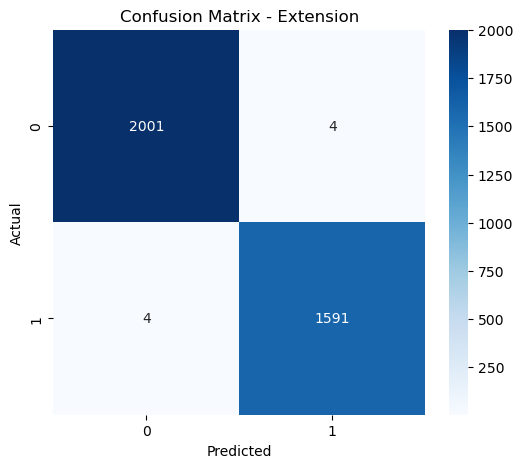

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Extension')
plt.show()

In [34]:
storeResults('Stacking',prop_acc,prop_prec,prop_rec,prop_f1)

# Voting Classifier

In [35]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=100,
    num_leaves=32,           
    random_state=42,
    n_jobs=-1
)

In [36]:
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier

ext = VotingClassifier(
    estimators=[('LDA', lda), ('Stack', stack), ('LightGBM', lgbm)],
    voting='soft'
)

ext.fit(X_train, y_train)

y_pred = ext.predict(X_test)

ext_acc = accuracy_score(y_pred, y_test)
ext_prec = precision_score(y_pred, y_test,average='weighted')
ext_rec = recall_score(y_pred, y_test,average='weighted')
ext_f1 = f1_score(y_pred, y_test,average='macro')

[LightGBM] [Info] Number of positive: 3746, number of negative: 4654
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 8400, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.445952 -> initscore=-0.217038
[LightGBM] [Info] Start training from score -0.217038
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

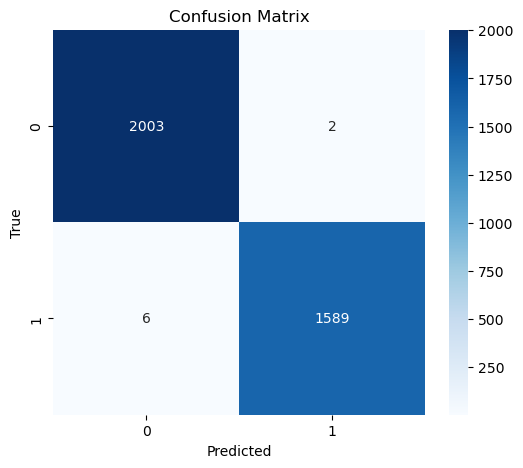

In [37]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [38]:
storeResults('Voting Classifier',ext_acc,ext_prec,ext_rec,ext_f1)

# Comparison

In [39]:
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Macro F1 score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                        
                      })

In [40]:
result

,ML Model,Accuracy,Macro F1 score,Recall,Precision
0,LDA,0.989,0.989,0.989,0.989
1,KNN,0.557,0.358,0.557,1.000
2,Random Forest,0.982,0.982,0.982,0.982
3,Stacking,0.998,0.998,0.998,0.998
4,Voting Classifier,0.998,0.998,0.998,0.998


# Modelling

In [41]:
import joblib

filename = 'models/afd_binary.sav'
joblib.dump(ext, filename)

['models/afd_binary.sav']

# Graph

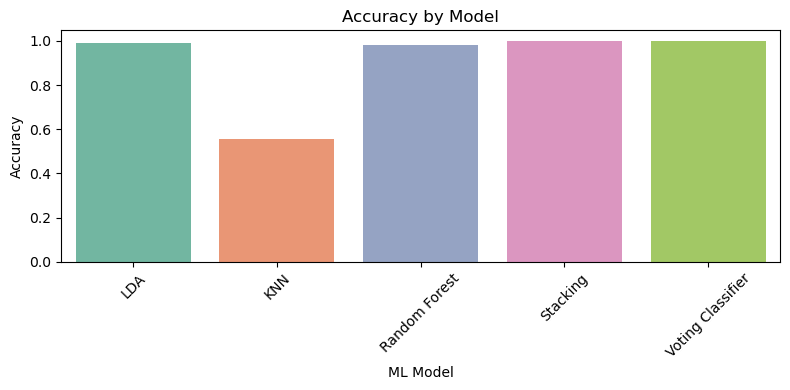

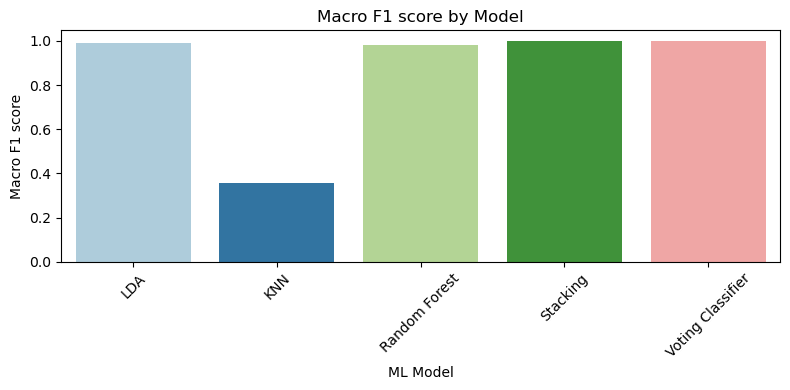

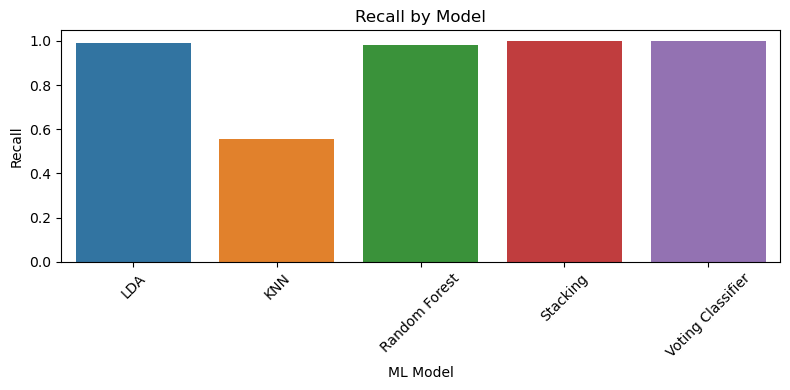

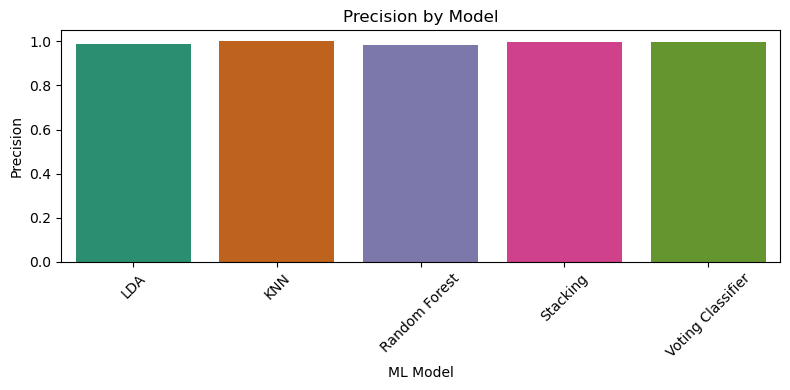

In [42]:
palettes = ['Set2', 'Paired', 'tab10', 'Dark2']

import matplotlib.pyplot as plt
import seaborn as sns

for metric, pal in zip(['Accuracy','Macro F1 score','Recall','Precision'], palettes):
    plt.figure(figsize=(8, 4))
    sns.barplot(data=result, x='ML Model', y=metric, palette=sns.color_palette(pal))
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Multi

In [43]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [44]:
y = data["Multi_Label"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.30, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8400, 17), (8400,), (3600, 17), (3600,))

# LDA

In [46]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(
    solver='lsqr',
    shrinkage=1   # equivalent to gamma regularization
)

lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

lda_acc = accuracy_score(y_pred, y_test)
lda_prec = precision_score(y_pred, y_test,average='weighted')
lda_rec = recall_score(y_pred, y_test,average='weighted')
lda_f1 = f1_score(y_pred, y_test,average='macro')

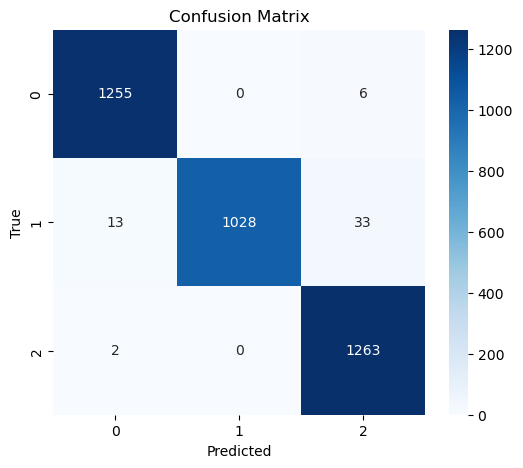

In [47]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [48]:
storeResults('LDA',lda_acc,lda_prec,lda_rec,lda_f1)

# KNN

In [49]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=20,
    metric='jaccard'
)

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='jaccard', n_neighbors=20)

In [50]:
y_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_pred, y_test)
knn_prec = precision_score(y_pred, y_test,average='weighted')
knn_rec = recall_score(y_pred, y_test,average='weighted')
knn_f1 = f1_score(y_pred, y_test,average='macro')

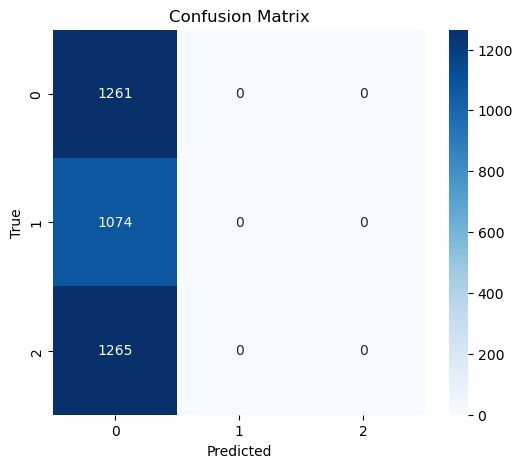

In [51]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [52]:
storeResults('KNN',knn_acc,knn_prec,knn_rec,knn_f1)

# Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='macro')

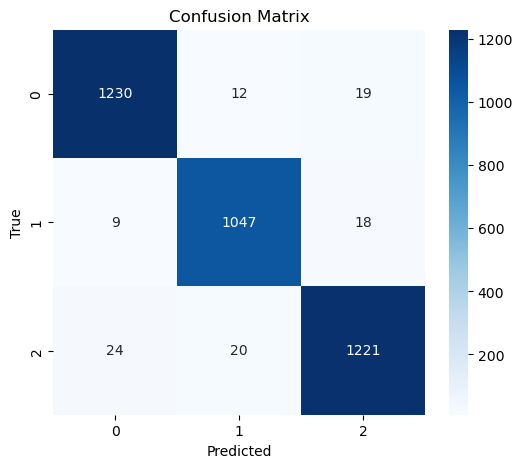

In [54]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [55]:
storeResults('Random Forest',rf_acc,rf_prec,rf_rec,rf_f1)

# Stacking Classifier

In [56]:
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier

base_learners = [
    ('lda', lda),
    ('rf', rf),
    ('knn', knn)
]

meta_learner = GradientBoostingClassifier(
    n_estimators=100,     # learning_cycles
    learning_rate=1,      # learning_rate
    min_samples_leaf=7,
    random_state=42
)

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner
)

stack.fit(X_train, y_train)

StackingClassifier(estimators=[('lda',
                                LinearDiscriminantAnalysis(shrinkage=1,
                                                           solver='lsqr')),
                               ('rf',
                                RandomForestClassifier(min_samples_leaf=10,
                                                       n_estimators=250,
                                                       random_state=42)),
                               ('knn',
                                KNeighborsClassifier(metric='jaccard',
                                                     n_neighbors=20))],
                   final_estimator=GradientBoostingClassifier(learning_rate=1,
                                                              min_samples_leaf=7,
                                                              random_state=42))

In [57]:
y_pred = stack.predict(X_test)

prop_acc = accuracy_score(y_pred, y_test)
prop_prec = precision_score(y_pred, y_test,average='weighted')
prop_rec = recall_score(y_pred, y_test,average='weighted')
prop_f1 = f1_score(y_pred, y_test,average='weighted')

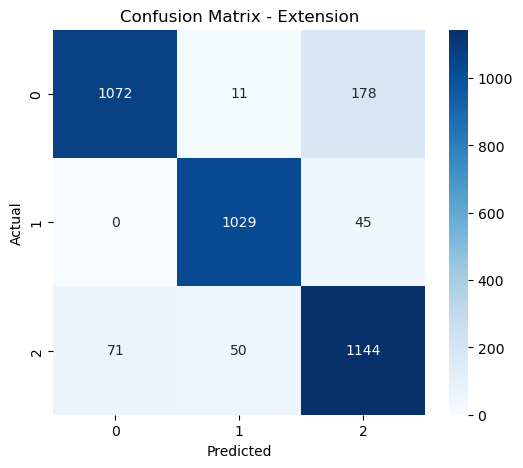

In [58]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Extension')
plt.show()

In [59]:
storeResults('Stacking',prop_acc,prop_prec,prop_rec,prop_f1)

# Voting Classifier

In [60]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=100,
    num_leaves=32,           
    random_state=42,
    n_jobs=-1
)

In [61]:
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier

ext = VotingClassifier(
    estimators=[('LDA', lda), ('Stack', stack), ('LightGBM', lgbm)],
    voting='soft'
)

ext.fit(X_train, y_train)

y_pred = ext.predict(X_test)

ext_acc = accuracy_score(y_pred, y_test)
ext_prec = precision_score(y_pred, y_test,average='weighted')
ext_rec = recall_score(y_pred, y_test,average='weighted')
ext_f1 = f1_score(y_pred, y_test,average='macro')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000760 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 8400, number of used features: 17
[LightGBM] [Info] Start training from score -1.081264
[LightGBM] [Info] Start training from score -1.215146
[LightGBM] [Info] Start training from score -1.010144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

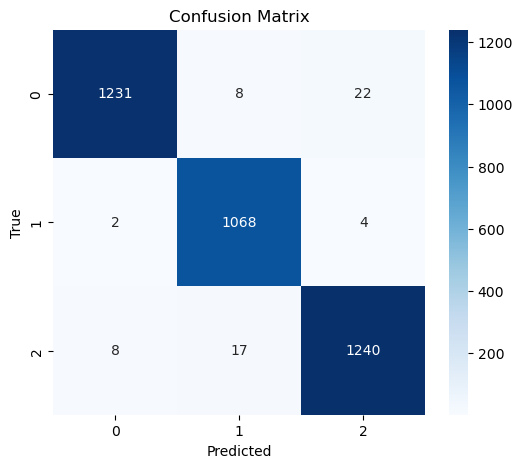

In [62]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [63]:
storeResults('Voting Classifier',ext_acc,ext_prec,ext_rec,ext_f1)

# Comparison

In [64]:
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Macro F1 score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                        
                      })

In [65]:
result

,ML Model,Accuracy,Macro F1 score,Recall,Precision
0,LDA,0.985,0.985,0.985,0.986
1,KNN,0.350,0.173,0.350,1.000
2,Random Forest,0.972,0.972,0.972,0.972
3,Stacking,0.901,0.901,0.901,0.903
4,Voting Classifier,0.983,0.983,0.983,0.983


# Modelling

In [66]:
import joblib

filename = 'models/afd_multi.sav'
joblib.dump(ext, filename)

['models/afd_multi.sav']

# Graph

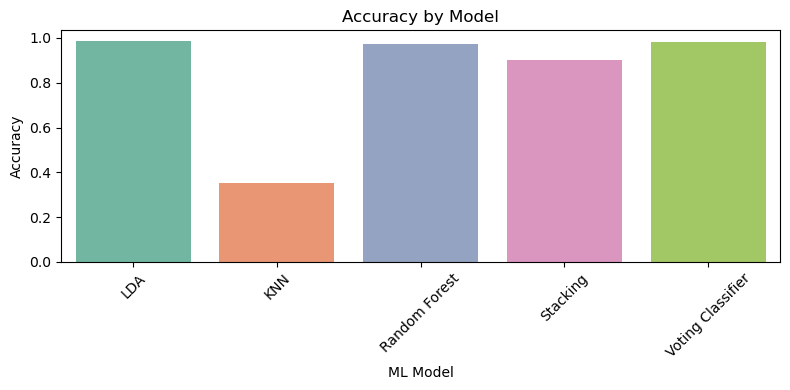

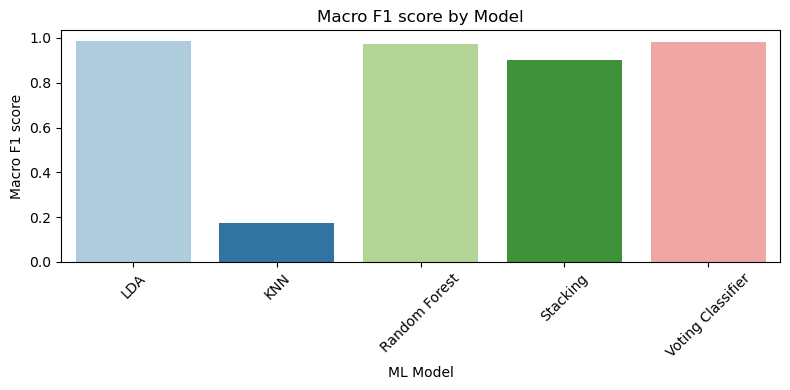

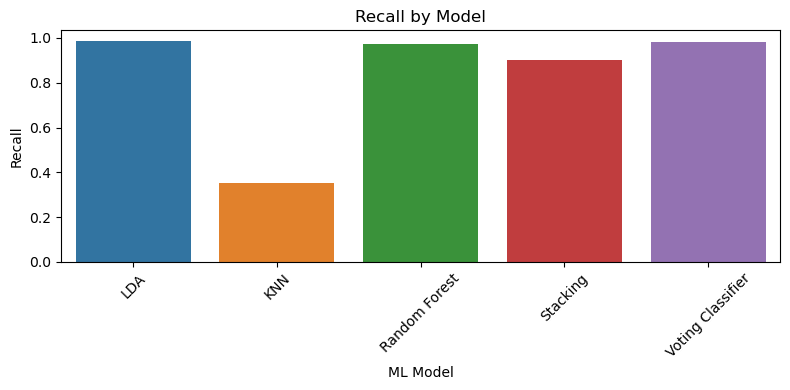

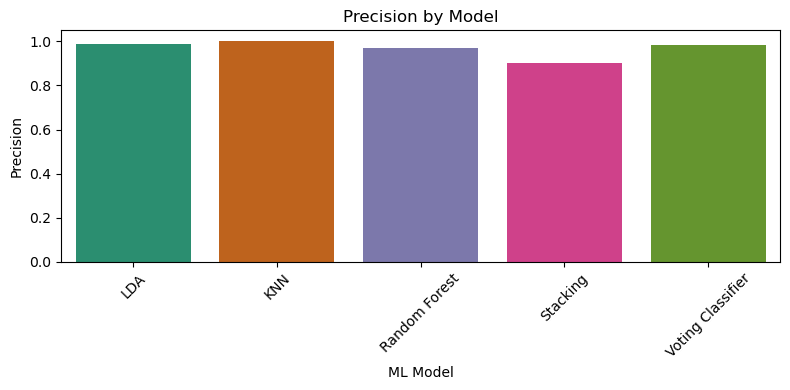

In [67]:
palettes = ['Set2', 'Paired', 'tab10', 'Dark2']

import matplotlib.pyplot as plt
import seaborn as sns

for metric, pal in zip(['Accuracy','Macro F1 score','Recall','Precision'], palettes):
    plt.figure(figsize=(8, 4))
    sns.barplot(data=result, x='ML Model', y=metric, palette=sns.color_palette(pal))
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# XAI

In [68]:
# importing lime
import lime
from lime import lime_tabular
import shap

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

In [70]:
background = (
    X_train.join(y_train)
            .groupby('Multi_Label', group_keys=False)        # <-- your class name
            .apply(lambda d: d.sample(n=max(1, min(10, len(d))), random_state=42))
            .drop(columns=['Multi_Label'])
)

X_test  = X_test.sample(n=1_00, random_state=42)
y_test  = y_test.loc[X_test.index]

In [71]:
lime_explainer = lime_tabular.LimeTabularExplainer(training_data=np.array(X_train), feature_names=X_train.columns, 
            class_names=['0','1','2'], mode='classification')

In [72]:
explanation = lime_explainer.explain_instance(data_row=X_test.iloc[1], predict_fn=ext.predict_proba, top_labels=10, num_features=15)
explanation.show_in_notebook()

In [73]:
def model_predict_class1(X):
    return ext.predict_proba(X)[:, 1]

In [74]:
# Then use this for SHAP
explainer = shap.KernelExplainer(model_predict_class1, data=background)
shap_values = explainer.shap_values(X_test, nsamples=10)

  0%|          | 0/100 [00:00<?, ?it/s]

In [75]:
shap.initjs()

# Convert feature row to NumPy
sample_features = X_test.iloc[0].values

# Correct force plot
shap.force_plot(explainer.expected_value, shap_values[0], sample_features, feature_names=X_test.columns)

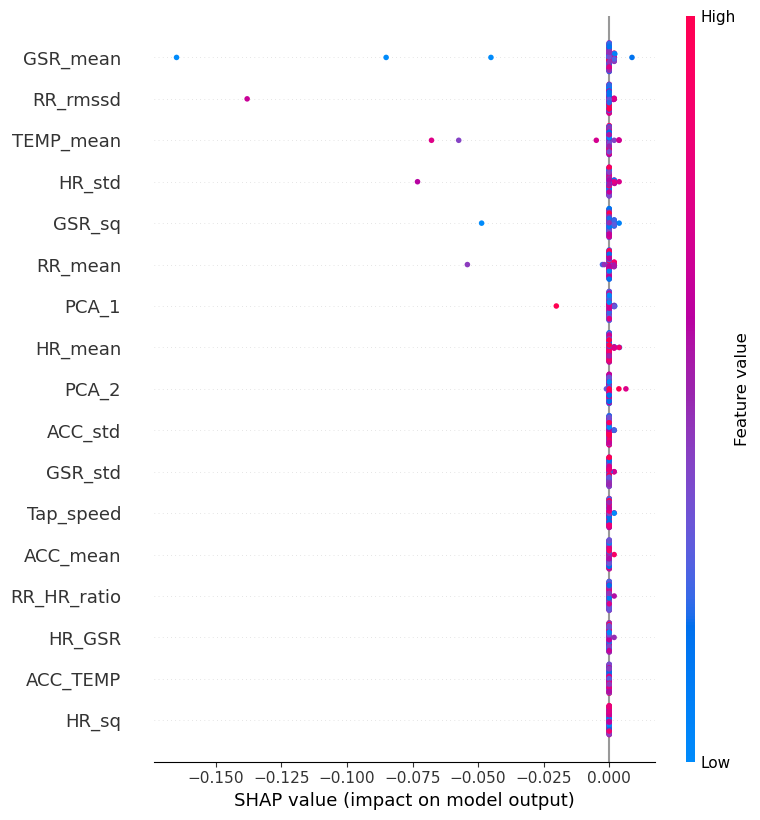

In [76]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)